<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/02_DL_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Optimization(최적화)**
- 데이터 사이언스 필드에서 주어진 문제에 대해 최소한의 비용으로 가장 빠르게 최선의 목표를 찾는 과정
- 모델의 학습을 효율적으로 시키기 위한 다양한 방법론을 통칭
- **model.compile** 에서 설정한 optimizer, loss, metric등
- 모델 학습 과정에서 설정가능한 여러가지 파라메터를 통해 모델을 효율적으로 학습시키기 위한 구조적인 장치



In [1]:
# 필요모듈 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
# 데이터로딩
# df = pd.read_csv('./california_housing.csv')
# y = df['target']
# X = df.drop('target', axis=1)
housing = fetch_california_housing()
y = housing['target']
X = housing['data']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## **1. Optimizer(최적화 알고리즘)**
- **back propagation(역전파 알고리즘)** 은 손실 함수(Loss Function)를 통해 계산된 미분값(Gradient)을 바탕으로 모델의 가중치(Weights)를 업데이트 하는 과정
- TensorFlow의 **Optimizer(최적화 알고리즘)** 은 가중치를 어느 방향(미분), 가속도(2차 미분)과 보폭(학습률)으로 업데이트할지 결정하는 핵심 엔진

### **1.1 주요 Optimizer 특징**

<div align="center">
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/62.png">
</div>

출처 : https://www.slideshare.net/slideshow/ss-79607172/79607172  

| Optimizer 이름 | 기본 학습률(lr) | 특징 및 활용 |
| :--- | :--- | :--- |
| **Adam** | 0.001  | 대부분의 모델에 잘 적용, 테스트 시 가장먼저 활용 시도 |
| **RMSProp** | 0.001 | 시계열 데이터 혹은 순환신경망에서 성능 좋음 |
| **SGD** | 0.01 | 학습이 매우 느리지만  momentum 추가 시 정교한 학습과정에서는 최고효율이 날 때도 있음 |
| **Adagrad** | 0.001 | sparse feature 데이터 학습 효율 좋음 |

- TensorFlow 공식 문서 : https://www.tensorflow.org/api_docs/python/tf/keras/optimizers

- 각 optimizer별 경사 하강 트래킹 시각화 소스 : https://emiliendupont.github.io/2018/01/24/optimization-visualization/

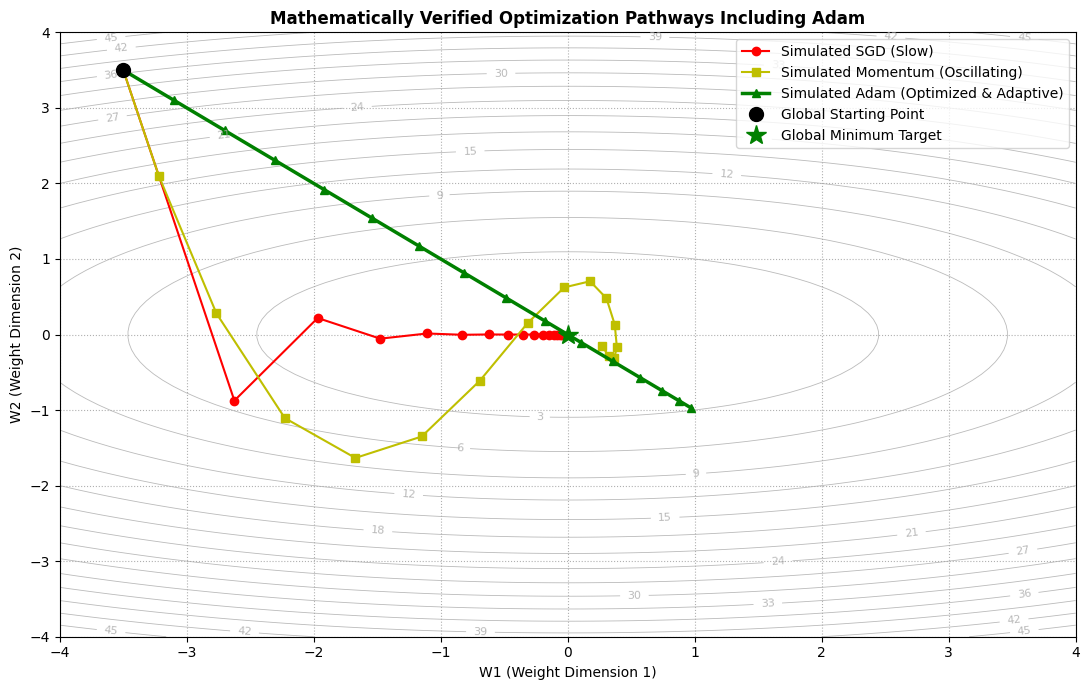

In [3]:
def compute_loss(w1: float, w2: float) -> float:
    # Mathematical formulation of the loss landscape: a steep elliptical valley
    return 0.5 * (w1**2 + 5.0 * (w2**2))


def compute_gradients(w1: float, w2: float) -> tuple[float, float]:
    # Exact analytical partial derivatives of the loss function
    dw1: float = w1
    dw2: float = 5.0 * w2
    return dw1, dw2


def simulate_sgd(
    start_w1: float, start_w2: float, lr: float, steps: int
) -> np.ndarray:
    w1, w2 = start_w1, start_w2
    path: list[list[float]] = [[w1, w2]]

    # Rigorous algorithmic execution of pure Stochastic Gradient Descent
    for _ in range(steps):
        dw1, dw2 = compute_gradients(w1, w2)
        w1 -= lr * dw1
        w2 -= lr * dw2
        path.append([w1, w2])
    return np.array(path)


def simulate_momentum(
    start_w1: float, start_w2: float, lr: float, beta: float, steps: int
) -> np.ndarray:
    w1, w2 = start_w1, start_w2
    v1, v2 = 0.0, 0.0
    path: list[list[float]] = [[w1, w2]]

    # Rigorous algorithmic execution of Momentum with accumulation of velocities
    for _ in range(steps):
        dw1, dw2 = compute_gradients(w1, w2)
        v1 = beta * v1 + lr * dw1
        v2 = beta * v2 + lr * dw2
        w1 -= v1
        w2 -= v2
        path.append([w1, w2])
    return np.array(path)


def simulate_adam(
    start_w1: float,
    start_w2: float,
    lr: float,
    beta1: float,
    beta2: float,
    epsilon: float,
    steps: int,
) -> np.ndarray:
    w1, w2 = start_w1, start_w2
    m1, m2 = 0.0, 0.0  # First moment vector (Momentum tracking)
    v1, v2 = 0.0, 0.0  # Second moment vector (RMSprop variance tracking)
    path: list[list[float]] = [[w1, w2]]

    # Rigorous algorithmic simulation of Adam including explicit Bias Correction mechanics
    for t in range(1, steps + 1):
        dw1, dw2 = compute_gradients(w1, w2)

        # Update biased first moment estimate
        m1 = beta1 * m1 + (1 - beta1) * dw1
        m2 = beta1 * m2 + (1 - beta1) * dw2

        # Update biased second raw moment estimate
        v1 = beta2 * v1 + (1 - beta2) * (dw1**2)
        v2 = beta2 * v2 + (1 - beta2) * (dw2**2)

        # Compute bias-corrected first moment estimate
        m1_hat: float = m1 / (1 - beta1**t)
        m2_hat: float = m2 / (1 - beta1**t)

        # Compute bias-corrected second raw moment estimate
        v1_hat: float = v1 / (1 - beta2**t)
        v2_hat: float = v2 / (1 - beta2**t)

        # Update parameters dynamically adjusting horizontal and vertical step lengths
        w1 -= lr * m1_hat / (np.sqrt(v1_hat) + epsilon)
        w2 -= lr * m2_hat / (np.sqrt(v2_hat) + epsilon)
        path.append([w1, w2])

    return np.array(path)


def plot_verified_trajectories_with_adam() -> None:
    # 1. Setup the loss surface contours grid
    w1_vals: np.ndarray = np.linspace(-4.0, 4.0, 100)
    w2_vals: np.ndarray = np.linspace(-4.0, 4.0, 100)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    Z: np.ndarray = compute_loss(W1, W2)

    # 2. Compute authentic algorithmic simulation pathways across identical starting points
    shared_start_w1: float = -3.5
    shared_start_w2: float = 3.5
    simulation_steps: int = 15

    sgd_path: np.ndarray = simulate_sgd(
        shared_start_w1, shared_start_w2, lr=0.25, steps=simulation_steps
    )
    momentum_path: np.ndarray = simulate_momentum(
        shared_start_w1,
        shared_start_w2,
        lr=0.08,
        beta=0.7,
        steps=simulation_steps,
    )
    adam_path: np.ndarray = simulate_adam(
        shared_start_w1,
        shared_start_w2,
        lr=0.4,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        steps=simulation_steps,
    )

    # 3. Canvas rendering stage
    plt.figure(figsize=(11, 7))
    contours = plt.contour(
        W1, W2, Z, levels=18, colors="darkgray", linewidths=0.6, alpha=0.8
    )
    plt.clabel(contours, inline=True, fontsize=8)

    # Plot verified trajectory tracks
    plt.plot(
        sgd_path[:, 0], sgd_path[:, 1], "r-o", label="Simulated SGD (Slow)"
    )
    plt.plot(
        momentum_path[:, 0],
        momentum_path[:, 1],
        "y-s",
        label="Simulated Momentum (Oscillating)",
    )
    plt.plot(
        adam_path[:, 0],
        adam_path[:, 1],
        "g-^",
        linewidth=2.5,
        label="Simulated Adam (Optimized & Adaptive)",
    )

    # Highlight landmarks explicitly
    plt.plot(
        shared_start_w1,
        shared_start_w2,
        "ko",
        markersize=10,
        label="Global Starting Point",
    )
    plt.plot(0.0, 0.0, "g*", markersize=15, label="Global Minimum Target")

    plt.title(
        "Mathematically Verified Optimization Pathways Including Adam",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("W1 (Weight Dimension 1)")
    plt.ylabel("W2 (Weight Dimension 2)")
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


# Execute the complete validation matrix simulation
plot_verified_trajectories_with_adam()

### **1.2 model2에 다른 optimizer 적용 후 학습곡선 확인**

In [23]:
# 랜덤 시드 설정
tf.random.set_seed(42)

# 기존 model1 로드
model1 = tf.keras.models.load_model('./complex_mlp.keras') # 모델 구조, compile, weights 까지 저장
# model1 clone_model로 여러개의 동일한 구조를 갖는 모델 생성
model2 = tf.keras.models.clone_model(model1)
model3 = tf.keras.models.clone_model(model1)
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,685 (6.59 KB)

 Trainable params: 561 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,124 (4.39 KB)

In [15]:
# adam
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# rmsprop
rmsprop_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)

# sgd
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

# sgd + momentum
sgd_momentum_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# modle1에 sgd + momentum optimizer적용
model1.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='mse',
    metrics=['mse']
)

# model2에 adam 적용
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mse']
)


In [17]:
# 각 모델 학습
history1 = model1.fit(X_train, y_train, epochs=30, validation_split=0.2)
history2 = model2.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 73.3609 - mse: 73.3609 - val_loss: 1.7599 - val_mse: 1.7599
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1204 - mse: 2.1204 - val_loss: 1.3155 - val_mse: 1.3155
Epoch 3/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.7570 - mse: 1.7570 - val_loss: 1.2892 - val_mse: 1.2892
Epoch 4/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3606 - mse: 1.3606 - val_loss: 0.9965 - val_mse: 0.9965
Epoch 5/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0102 - mse: 1.0102 - val_loss: 1.0454 - val_mse: 1.0454
Epoch 6/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8456 - mse: 0.8456 - val_loss: 0.9440 - val_mse: 0.9440
Epoch 7/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8077 - mse: 0.8077 - val_loss: 0.8644 - val_mse: 0.8644
Epoch 8/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8775 - mse: 0.8775 - val_loss: 0.7950 - val_mse: 0.7950
Epoch 9/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

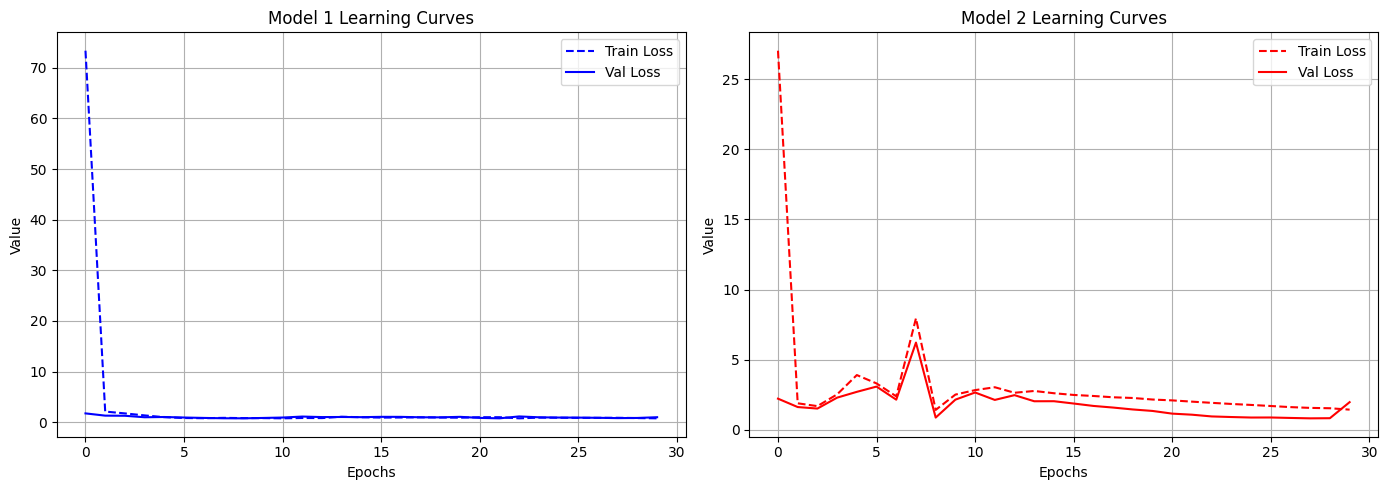

In [18]:
# 모델 history 러닝커브 비교 시각화
def plot_separated_learning_curves(history1, history2):
    # Create a 1x2 grid for subplots
    plt.figure(figsize=(14, 5))

    # 1. First subplot: Model 1 (history1) Learning Curves
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['loss'], label='Train Loss', color='blue', linestyle='--')
    if 'val_loss' in history1.history:
        plt.plot(history1.history['val_loss'], label='Val Loss', color='blue')

    # plt.plot(history1.history['mse'], label='Train MSE', color='cyan', linestyle='--')
    # if 'val_mse' in history1.history:
    #     plt.plot(history1.history['val_mse'], label='Val MSE', color='cyan')

    plt.title('Model 1 Learning Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    # 2. Second subplot: Model 2 (history2) Learning Curves
    plt.subplot(1, 2, 2)
    plt.plot(history2.history['loss'], label='Train Loss', color='red', linestyle='--')
    if 'val_loss' in history2.history:
        plt.plot(history2.history['val_loss'], label='Val Loss', color='red')

    # plt.plot(history2.history['mse'], label='Train MSE', color='orange', linestyle='--')
    # if 'val_mse' in history2.history:
    #     plt.plot(history2.history['val_mse'], label='Val MSE', color='orange')

    plt.title('Model 2 Learning Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    # Display the plots
    plt.tight_layout()
    plt.show()

# Example usage:
plot_separated_learning_curves(history1, history2)

## **2. learning rate(학습률)**
- chain rule을 통해 구해지는 gradient(미분) 값에 학습률을 곱해 weights(가중치)를 업데이트  
- 값의 부호 반대방향으로 가중치를 업데이트 한다.  
- 너무 큰 업데이트값을 사용함으로서 모델 학습이 되지 않거나(발산) 너무 작은 업데이트 값을 곱해 학습이 더뎌지는 문제가 발생 가능
- 가중치 X 학습률 $\eta$ 만큼 업데이트 하면서 최적값을 찾는 과정을 거친다.
# $$W \leftarrow W - \eta{{\partial j}(W)\over{\partial W}}$$


<div align="center">
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/63.png">
</div>

출처 : https://cs231n.github.io/neural-networks-3/

### **2.1 learning rate 값에 따른 학습 곡선 확인**
모델의 learning rate는 model.compile 과정에서 최적화 알고리즘에 따라 설정이 가능하다.  
학습되는 과정을 살펴보기 위해 조금은 복잡한 구조에 sigmoid activation을 사용하며  
optimizer를 SGD, Adam을 사용하여 각 학습률에 따른 러닝 커브를 확인한다면  
학습률에 따른 학습과정을 살펴볼 수 있다.

In [24]:
# adam 0.001, 0.0003, 0.0001
# SGD 0.001, 0.0001, 0.0003

# adam 기준 위의 LR 적용한 3개의 모델 생성 후 compile
# model3
model3 = tf.keras.models.clone_model(model1)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mse']
    )
# model4
model4 = tf.keras.models.clone_model(model1)
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00003),
    loss='mse',
    metrics=['mse']
    )

# model5
model5 = tf.keras.models.clone_model(model1)
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='mse',
    metrics=['mse']
    )

In [25]:
# 모델 학습
history3 = model3.fit(X_train, y_train, epochs=30, validation_split=0.2)
history4 = model4.fit(X_train, y_train, epochs=30, validation_split=0.2)
history5 = model5.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 39.8182 - mse: 39.8182 - val_loss: 15.5203 - val_mse: 15.5203
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.0810 - mse: 8.0810 - val_loss: 4.1458 - val_mse: 4.1458
Epoch 3/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7986 - mse: 2.7986 - val_loss: 1.7628 - val_mse: 1.7628
Epoch 4/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6572 - mse: 1.6572 - val_loss: 1.5924 - val_mse: 1.5924
Epoch 5/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5337 - mse: 1.5337 - val_loss: 1.4790 - val_mse: 1.4790
Epoch 6/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4383 - mse: 1.4383 - val_loss: 1.3956 - val_mse: 1.3956
Epoch 7/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3587 - mse: 1.3587 - val_loss: 1.3214 - val_mse: 1.3214
Epoch 8/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2901 - mse: 1.2901 - val_loss: 1.2612 - val_mse: 1.2612
Epoch 9/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

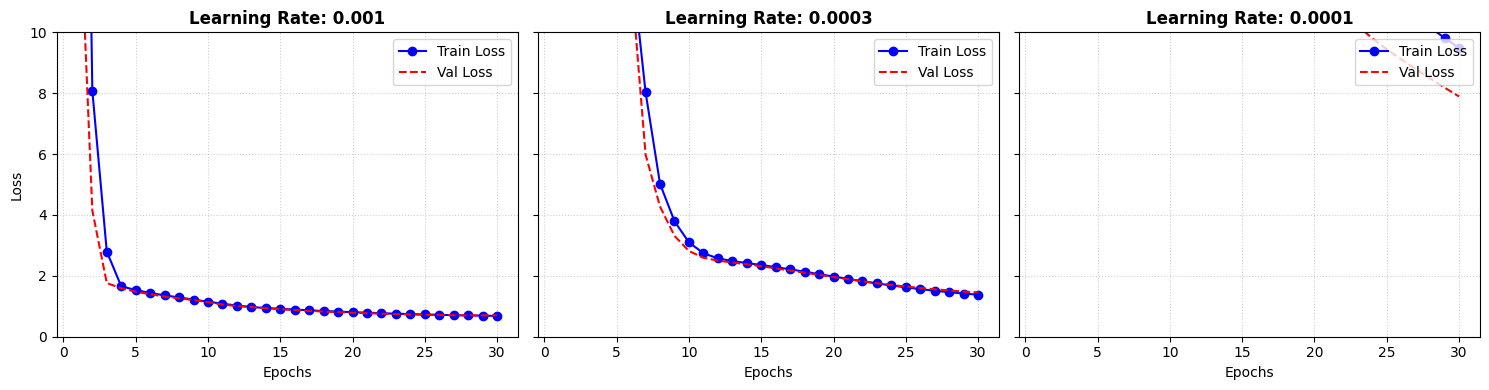

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# ---------------------------------------------------------------------------
# Subplot 1: Model 1 (Learning Rate: 0.03)
# ---------------------------------------------------------------------------
epochs1: range = range(1, len(history3.history['loss']) + 1)
axes[0].plot(epochs1, history3.history['loss'], label='Train Loss', color='blue', marker='o')
axes[0].plot(epochs1, history3.history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[0].set_title('Learning Rate: 0.001', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Loss', fontsize=10)
axes[0].set_ylim(0, 10)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# ---------------------------------------------------------------------------
# Subplot 2: Model 2 (Learning Rate: 0.0003)
# ---------------------------------------------------------------------------
epochs2: range = range(1, len(history4.history['loss']) + 1)
axes[1].plot(epochs2, history4.history['loss'], label='Train Loss', color='blue', marker='o')
axes[1].plot(epochs2, history4.history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[1].set_title('Learning Rate: 0.0003', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylim(0, 10)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

# ---------------------------------------------------------------------------
# Subplot 3: Model 3 (Learning Rate: 0.0001)
# ---------------------------------------------------------------------------
epochs3: range = range(1, len(history5.history['loss']) + 1)
axes[2].plot(epochs3, history5.history['loss'], label='Train Loss', color='blue', marker='o')
axes[2].plot(epochs3, history5.history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[2].set_title('Learning Rate: 0.0001', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epochs', fontsize=10)
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.6)

fig.tight_layout()
# fig.savefig('tf_models_learning_rate_curves.png', dpi=300)